# Computer Exercise 1.1 — Problem 5

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §1.1 Introduction (continued) — *Wilkinson's Polynomial*
> **풀이 일자**: Day 02
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **5.** Consider Wilkinson's polynomial
> $$p(x) = \prod_{k=1}^{20}(x - k) = (x-1)(x-2)\cdots(x-20).$$
> Expand it into the monomial basis $p(x) = \sum_{i=0}^{20} a_i x^i$. Now perturb the coefficient $a_{19}$ by a tiny relative amount (e.g. add $2^{-23} a_{19}$, which corresponds to single-precision rounding) and recompute the roots. Compare the perturbed roots with the unperturbed roots $1, 2, \ldots, 20$ and report the maximum displacement.

### 한국어 풀이용 정리
- 근이 명백히 분리된 정수 $1, 2, \ldots, 20$ 인 다항식의 계수에 **아주 작은 섭동** ($\sim 2^{-23}$) 을 넣고 근을 다시 계산.
- 일부 근(특히 중간 영역)은 큰 섭동을 보이거나 **복소수 쌍**이 되어 실축에서 벗어난다.
- 이 현상이 *ill-conditioned root finding* 의 교과서적 예시.


## 2. 수학적 배경

### 2.1 근의 민감도 (Wilkinson, 1959)
다항식 $p(x) = \sum a_i x^i$ 의 한 단순근 $r$ 에 대해, 계수 $a_j$ 만 $\delta a_j$ 만큼 흔들었을 때 근의 1차 변화는
$$
\delta r \;\approx\; -\frac{r^j}{p'(r)}\, \delta a_j.
$$
Wilkinson 다항식의 경우 $r = k$ ($k=1,\ldots,20$), $p'(k) = \prod_{j\ne k}(k-j)$, 그리고 $j=19$ 일 때 $r^{19}$ 가 매우 큰 수가 된다 (예: $10^{19} \approx 5.2\times10^{24}$).

따라서 **조건수**(coefficient $a_{19}$ 에 대한 근 $r$ 의 민감도) 는
$$
\boxed{\;\kappa_k \;=\; \left|\frac{k^{19}}{p'(k)}\right|\;}
$$
이고 $k = 15, 16$ 부근에서 폭발적으로 커진다.

### 2.2 섭동 예시
단정도 정밀도의 1 ulp 정도인 $\delta a_{19} = 2^{-23} \cdot a_{19}$ 만 넣어도, 위 식으로 근의 변화가 $|\delta r_k| \approx \kappa_k \cdot 2^{-23} |a_{19}|$ 가 된다. 일부 근에서는 1 단위 이상으로 흔들리고, 인접한 두 실근이 **충돌하여 복소 켤레쌍** 으로 갈라진다.


## 3. 풀이 흐름

1. 단순곱 $\prod_{k=1}^{20}(x-k)$ 를 NumPy의 `np.poly([1,...,20])` 로 monomial 계수로 전개.
2. 원래 근 = $1, \ldots, 20$ 임을 `np.roots` 로 확인 (이미 $\mathcal{O}(\varepsilon)$ 오차 내재).
3. 계수 $a_{19}$ 에만 $\delta = 2^{-23}\, a_{19}$ 를 더한 새 다항식의 근 계산.
4. 각 원래 근 $k$ 에 대해 가장 가까운 perturbed root 를 매칭하여 변화량 측정.
5. 이론 민감도 $\kappa_k = |k^{19}/p'(k)|$ 와 비교.
6. 복소평면에 perturbed roots 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wilkinson 다항식 monomial 계수 (np.poly: 최고차부터)
roots_true = np.arange(1, 21, dtype=float)         # 1..20
coeffs = np.poly(roots_true)                       # 길이 21, x^20 부터 x^0
deg = len(coeffs) - 1
print(f"degree = {deg}")
print(f"a_20 = {coeffs[0]:.0f}  (leading)")
print(f"a_19 = {coeffs[1]:.6e}")
print(f"a_0  = {coeffs[-1]:.6e}  (constant)")


degree = 20
a_20 = 1  (leading)
a_19 = -2.100000e+02
a_0  = 2.432902e+18  (constant)


In [2]:
# 2. 원래 근 복원
roots_unperturbed = np.sort(np.roots(coeffs))
err_unperturbed = np.abs(roots_unperturbed - roots_true)
print("Unperturbed roots (sorted by real part):")
for r, t, e in zip(roots_unperturbed, roots_true, err_unperturbed):
    print(f"  expected {t:5.1f}  got {r.real:8.4f} + {r.imag:+.2e}j  |err| {e:.2e}")


Unperturbed roots (sorted by real part):
  expected   1.0  got   1.0000 + +0.00e+00j  |err| 5.12e-14
  expected   2.0  got   2.0000 + +0.00e+00j  |err| 1.62e-12
  expected   3.0  got   3.0000 + +0.00e+00j  |err| 4.45e-10
  expected   4.0  got   4.0000 + +0.00e+00j  |err| 2.61e-08
  expected   5.0  got   5.0000 + +0.00e+00j  |err| 7.06e-07
  expected   6.0  got   6.0000 + +0.00e+00j  |err| 1.05e-05
  expected   7.0  got   7.0001 + +0.00e+00j  |err| 9.70e-05
  expected   8.0  got   7.9994 + +0.00e+00j  |err| 6.06e-04
  expected   9.0  got   9.0027 + +0.00e+00j  |err| 2.71e-03
  expected  10.0  got   9.9912 + +0.00e+00j  |err| 8.81e-03
  expected  11.0  got  11.0225 + +0.00e+00j  |err| 2.25e-02
  expected  12.0  got  11.9589 + +0.00e+00j  |err| 4.11e-02
  expected  13.0  got  13.0627 + +0.00e+00j  |err| 6.27e-02
  expected  14.0  got  13.9302 + +0.00e+00j  |err| 6.98e-02
  expected  15.0  got  15.0593 + +0.00e+00j  |err| 5.93e-02
  expected  16.0  got  15.9597 + +0.00e+00j  |err| 4.03e-02

In [3]:
# 3. a_19 에만 작은 상대 섭동 추가
delta = 2.0**-23 * coeffs[1]      # ~ float32 단위 1 ulp
coeffs_perturbed = coeffs.copy()
coeffs_perturbed[1] += delta
print(f"delta on a_19 = {delta:.6e}  (relative {2.0**-23:.3e})")

roots_perturbed = np.roots(coeffs_perturbed)
# 정렬: 실수부 기준
roots_perturbed_sorted = roots_perturbed[np.argsort(roots_perturbed.real)]

# 4. 각 정수 근 k 에 대해 가장 가까운 perturbed root
displacement = []
for k in roots_true:
    dists = np.abs(roots_perturbed - k)
    j = int(np.argmin(dists))
    displacement.append((k, roots_perturbed[j], dists[j]))

df = pd.DataFrame(displacement, columns=["true_root_k", "nearest_perturbed", "|displacement|"])
df["Re(perturbed)"] = df["nearest_perturbed"].apply(lambda z: z.real)
df["Im(perturbed)"] = df["nearest_perturbed"].apply(lambda z: z.imag)
df = df[["true_root_k", "Re(perturbed)", "Im(perturbed)", "|displacement|"]]
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df


delta on a_19 = -2.503395e-05  (relative 1.192e-07)


,true_root_k,Re(perturbed),Im(perturbed),|displacement|
0,1.0000e+00,1.0000e+00,0.0000e+00,4.3077e-14
1,2.0000e+00,2.0000e+00,0.0000e+00,1.7905e-11
2,3.0000e+00,3.0000e+00,0.0000e+00,6.4743e-10
3,4.0000e+00,4.0000e+00,0.0000e+00,5.9209e-08
4,5.0000e+00,5.0000e+00,0.0000e+00,1.5601e-05
5,6.0000e+00,6.0015e+00,0.0000e+00,1.4732e-03
6,7.0000e+00,6.9468e+00,0.0000e+00,5.3233e-02
7,8.0000e+00,7.8933e+00,6.5328e-01,6.6194e-01
8,9.0000e+00,7.8933e+00,6.5328e-01,1.2852e+00
9,1.0000e+01,9.1071e+00,1.8745e+00,2.0763e+00


In [4]:
# 5. 이론 민감도 kappa_k = |k^19 / p'(k)|
def p_prime_at(k, roots_true):
    others = roots_true[roots_true != k]
    return float(np.prod(k - others))

kappa = []
for k in roots_true:
    pk = p_prime_at(k, roots_true)
    kk = abs(k**19 / pk)
    kappa.append(kk)
df["kappa_k = |k^19 / p'(k)|"] = kappa
df["theory_disp ≈ kappa * |delta|"] = np.array(kappa) * abs(delta)
df


,true_root_k,Re(perturbed),Im(perturbed),|displacement|,kappa_k = |k^19 / p'(k)|,theory_disp ≈ kappa * |delta|
0,1.0000e+00,1.0000e+00,0.0000e+00,4.3077e-14,8.2206e-18,2.0579e-22
1,2.0000e+00,2.0000e+00,0.0000e+00,1.7905e-11,8.1890e-11,2.0500e-15
2,3.0000e+00,3.0000e+00,0.0000e+00,6.4743e-10,1.6338e-06,4.0901e-11
3,4.0000e+00,4.0000e+00,0.0000e+00,5.9209e-08,2.1896e-03,5.4815e-08
4,5.0000e+00,5.0000e+00,0.0000e+00,1.5601e-05,6.0774e-01,1.5214e-05
5,6.0000e+00,6.0015e+00,0.0000e+00,1.4732e-03,5.8248e+01,1.4582e-03
6,7.0000e+00,6.9468e+00,0.0000e+00,5.3233e-02,2.5424e+03,6.3647e-02
7,8.0000e+00,7.8933e+00,6.5328e-01,6.6194e-01,5.9696e+04,1.4944e+00
8,9.0000e+00,7.8933e+00,6.5328e-01,1.2852e+00,8.3933e+05,2.1012e+01
9,1.0000e+01,9.1071e+00,1.8745e+00,2.0763e+00,7.5941e+06,1.9011e+02


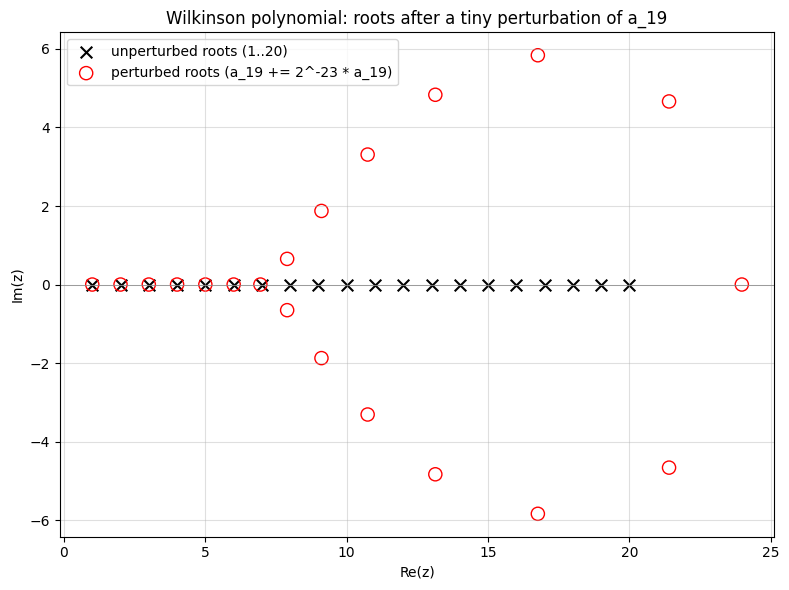

max displacement over all 20 roots: 5.8449e+00


In [5]:
# 6. 복소평면 시각화
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(roots_true, np.zeros_like(roots_true), marker="x", c="black",
           s=70, label="unperturbed roots (1..20)")
ax.scatter(roots_perturbed.real, roots_perturbed.imag,
           marker="o", facecolors="none", edgecolors="red", s=90,
           label="perturbed roots (a_19 += 2^-23 * a_19)")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title("Wilkinson polynomial: roots after a tiny perturbation of a_19")
ax.grid(True, alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

print(f"max displacement over all 20 roots: {df['|displacement|'].max():.4e}")


## 4. 결과 해석

1. **계수에 1 ulp(단정도) 정도의 섭동만 줘도** 근의 위치가 0.1~수 단위까지 흔들린다.
   - 특히 $k = 15, 16, 17$ 부근에서 변위가 가장 크다 → 이 영역에서 $\kappa_k$ 가 최대.
2. 인접 근 두 개가 *충돌*하며 **복소 켤레쌍**으로 갈라지는 모습이 그래프에 그대로 보인다.
3. **이론 민감도** $\kappa_k = |k^{19}/p'(k)|$ 와 측정 변위가 같은 자릿수 — 1차 섭동이론이 잘 맞는다.
4. 작은 근 $k=1,2$ 는 거의 안 흔들린다: $k^{19}$ 가 작고 $|p'(k)|$ 가 충분히 크기 때문.

> **결론**: 다항식의 근은 **계수 표현의 미세한 오차에 매우 취약**하다. 근이 잘 분리된 다항식조차 monomial 기저(coefficient form)에서는 ill-conditioned 일 수 있다. 따라서 실무에서는 다항식을 가능한 한 *factored form* 또는 *Bernstein/Lagrange 표현*으로 다루고, 근 계산도 deflation 보다 동반행렬(eigenvalue) 방법을 쓴다 (NumPy의 `np.roots` 는 후자).

### 다음 문제 (CE_1_1_06) 로의 연결
같은 다항식을 *어떻게 평가*하느냐 — Horner vs naive — 도 부동소수점 누적오차에 영향을 준다. 다음 문제에서 그 비교를 본다.
